In [1]:
import numpy as np
import pandas as pd
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

In [2]:
# Lista para almacenar los DataFrames leídos
dataframes = []

# Leer los archivos CSV que contienen los DataFrames
archivos = ['datos-1011.csv','datos-1112.csv','datos-1213.csv','datos-1314.csv',
            'datos-1415.csv','datos-1516.csv', 'datos-1617.csv', 'datos-1718.csv',
            'datos-1819.csv', 'datos-1920.csv', 'datos-2021.csv', 'datos-2122.csv', 
            'datos-2223.csv', 'datos-2324.csv']

archivos_segunda = ['datos-SP2-1011.csv','datos-SP2-1112.csv',
            'datos-SP2-1213.csv','datos-SP2-1314.csv','datos-SP2-1415.csv','datos-SP2-1516.csv', 
            'datos-SP2-1617.csv', 'datos-SP2-1718.csv','datos-SP2-1819.csv', 'datos-SP2-1920.csv', 
            'datos-SP2-2021.csv', 'datos-SP2-2122.csv', 'datos-SP2-2223.csv', 'datos-SP2-2324.csv']

#archivos += archivos_segunda

for archivo in archivos:
    # Leer el archivo y almacenar el DataFrame en la lista
    df = pd.read_csv("../Segundo_Dataset/Datos_Formateados/"+archivo)
    dataframes.append(df)

# Concatenar todos los DataFrames en uno solo
datos_partidos = pd.concat(dataframes, ignore_index=True)
datos_partidos.shape

(5199, 9)

In [3]:
def get_equipos(dataframe: pd.DataFrame) -> list:
    list = []
    for idx in dataframe.index:
        if dataframe['HomeTeam'][idx] not in list:
            list.append(dataframe['HomeTeam'][idx])
        if dataframe['AwayTeam'][idx] not in list:
            list.append(dataframe['AwayTeam'][idx])
    return list

equipos = get_equipos(dataframe=datos_partidos)
equipos

['Hercules',
 'Ath Bilbao',
 'Levante',
 'Sevilla',
 'Malaga',
 'Valencia',
 'Espanol',
 'Getafe',
 'La Coruna',
 'Zaragoza',
 'Mallorca',
 'Real Madrid',
 'Osasuna',
 'Almeria',
 'Santander',
 'Barcelona',
 'Sociedad',
 'Villarreal',
 'Ath Madrid',
 'Sp Gijon',
 'Granada',
 'Betis',
 'Vallecano',
 'Celta',
 'Valladolid',
 'Elche',
 'Eibar',
 'Cordoba',
 'Las Palmas',
 'Alaves',
 'Leganes',
 'Girona',
 'Huesca',
 'Cadiz']

In [4]:
condicion = (datos_partidos['FTR'] != 'A') & (datos_partidos['FTR'] != 'H') & (datos_partidos['FTR'] != 'D')
datos_partidos = datos_partidos.drop(datos_partidos[condicion].index)

In [5]:
def calcular_racha_invicto(fila_actual, racha_anterior, local):
    if local == True:
        resultado_actual = fila_actual['FTR']
        if resultado_actual == 'H':
            racha_actual = racha_anterior+1
        elif resultado_actual == 'D':
            racha_actual = racha_anterior
        else:
            racha_actual = 0
        return racha_actual
    else:
        resultado_actual = fila_actual['FTR']
        if resultado_actual == 'A':
            racha_actual = racha_anterior+1
        elif resultado_actual == 'D':
            racha_actual = racha_anterior
        else:
            racha_actual = 0
        return racha_actual


for equipo in equipos:
    nueva_columna_valores = []
    racha_actual = 0
    first = True
    filas_filtradas = datos_partidos[datos_partidos['HomeTeam'] == equipo]
    for indice, fila_actual in filas_filtradas.iterrows():
        if first:
            first = False
            nueva_columna_valores.append(0)
            racha_actual = calcular_racha_invicto(fila_actual, racha_actual, True)
        else:
            nueva_columna_valores.append(racha_actual)
            racha_actual = calcular_racha_invicto(fila_actual, racha_actual, True)

    datos_partidos.loc[filas_filtradas.index, 'Racha_Local'] = nueva_columna_valores
    
for equipo in equipos:
    nueva_columna_valores = []
    racha_actual = 0
    first = True
    filas_filtradas = datos_partidos[datos_partidos['AwayTeam'] == equipo]
    for indice, fila_actual in filas_filtradas.iterrows():
        if first:
            first = False
            nueva_columna_valores.append(0)
            racha_actual = calcular_racha_invicto(fila_actual, racha_actual, False)
        else:
            nueva_columna_valores.append(racha_actual)
            racha_actual = calcular_racha_invicto(fila_actual, racha_actual, False)

    datos_partidos.loc[filas_filtradas.index, 'Racha_Visitante'] = nueva_columna_valores
    
datos_partidos.to_csv("intermedio.csv")

In [6]:
lb_make = LabelEncoder()
datos_partidos['target_FTR'] = lb_make.fit_transform(datos_partidos['FTR'])
datos_partidos['FTR'].value_counts()
label_encoder = LabelEncoder()
datos_partidos['labeled_Home'] = label_encoder.fit_transform(datos_partidos['HomeTeam'])
datos_partidos['labeled_Away'] = label_encoder.fit_transform(datos_partidos['AwayTeam'])
datos_partidos['target_FTR'].value_counts()

target FTR
2    2425
0    1468
1    1306
Name: count, dtype: int64

<Axes: ylabel='Density'>

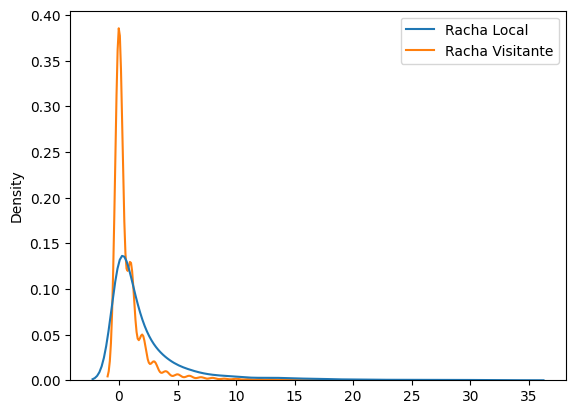

In [7]:
columnas_de_rachas=['Racha_Local', 'Racha_Visitante']
rachas = datos_partidos[columnas_de_rachas]
sns.kdeplot(data=datos_partidos[['Racha_Local', 'Racha_Visitante']])

<Axes: ylabel='Density'>

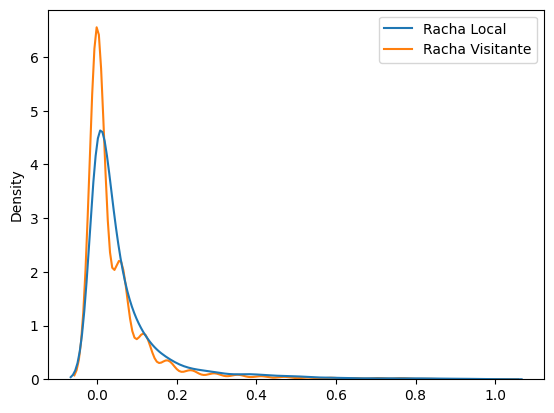

In [8]:
scale = MinMaxScaler().fit(rachas)
rachas_normalized = scale.transform(rachas)
rachas_normalized_dataframe = pd.DataFrame(rachas_normalized, columns=columnas_de_rachas)
sns.kdeplot(data=rachas_normalized_dataframe[['Racha_Local', 'Racha_Visitante']])

In [9]:
rachas_normalized_dataframe.shape

(5199, 2)

In [10]:
datos_partidos[rachas_normalized_dataframe.columns] = rachas_normalized_dataframe
datos_partidos.to_csv("prueba.csv")
datos_partidos.shape

(5199, 14)

In [11]:
equipos_locales = datos_partidos['labeled_Home']
equipos_visitantes = datos_partidos['labeled_Away']
racha_local = datos_partidos['Racha_Local']
racha_visitante = datos_partidos['Racha_Visitante']
target = datos_partidos['target_FTR']

In [12]:
target = to_categorical(target)
target.shape

(5199, 3)

In [13]:
features = pd.concat([equipos_locales,equipos_visitantes, racha_local, racha_visitante], axis=1)

In [14]:
features_train, features_test, target_train, target_test = train_test_split( features, target, test_size=0.3, random_state=42)
print ('Train set:', features_train.shape,  target_train.shape)
print ('Test set:', features_test.shape,  target_test.shape)

Train set: (3639, 4) (3639, 3)
Test set: (1560, 4) (1560, 3)
